``Open in colab``

# Práctica 1: Estudio comparativo de algoritmos en un problema de k-armed bandit

**Descripción**: Description: El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit. Se generan gráficas de recompensas promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

## Preparación del entorno

!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

!pip install -r requirements.txt

In [1]:

from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

In [2]:
import os
import gc
import torch
import numpy as np
#import gymnasium as gym
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren

# Configuración de la semilla para reproducibilidad
seed = 123 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

# Fijar la semilla en Gymnasium
#def make_env(env_name):
#    env = gym.make(env_name)
#    env.reset(seed=seed) # Establece la semilla en el entorno de Gymnasium
#    return env

# Ejemplo de creación de un entorno con semilla
env_name = "CartPole-v1" # Cambiar según el entorno deseado

Usando dispositivo: cpu


In [3]:


k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Algoritmo  ε-greedy

## Experimentos

In [4]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])



    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = int(arm_data["counts"]/runs)

    return rewards, optimal_selections, arm_stats, regrets

## ``Experimento distribución Normal``

In [5]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=3.04, sigma=1.0), ArmNormal(mu=3.58, sigma=1.0), ArmNormal(mu=5.96, sigma=1.0), ArmNormal(mu=4.81, sigma=1.0), ArmNormal(mu=7.48, sigma=1.0), ArmNormal(mu=7.27, sigma=1.0), ArmNormal(mu=9.83, sigma=1.0), ArmNormal(mu=7.16, sigma=1.0), ArmNormal(mu=5.33, sigma=1.0), ArmNormal(mu=4.53, sigma=1.0)
Optimal arm: 7 with expected reward=9.83


### Visualización

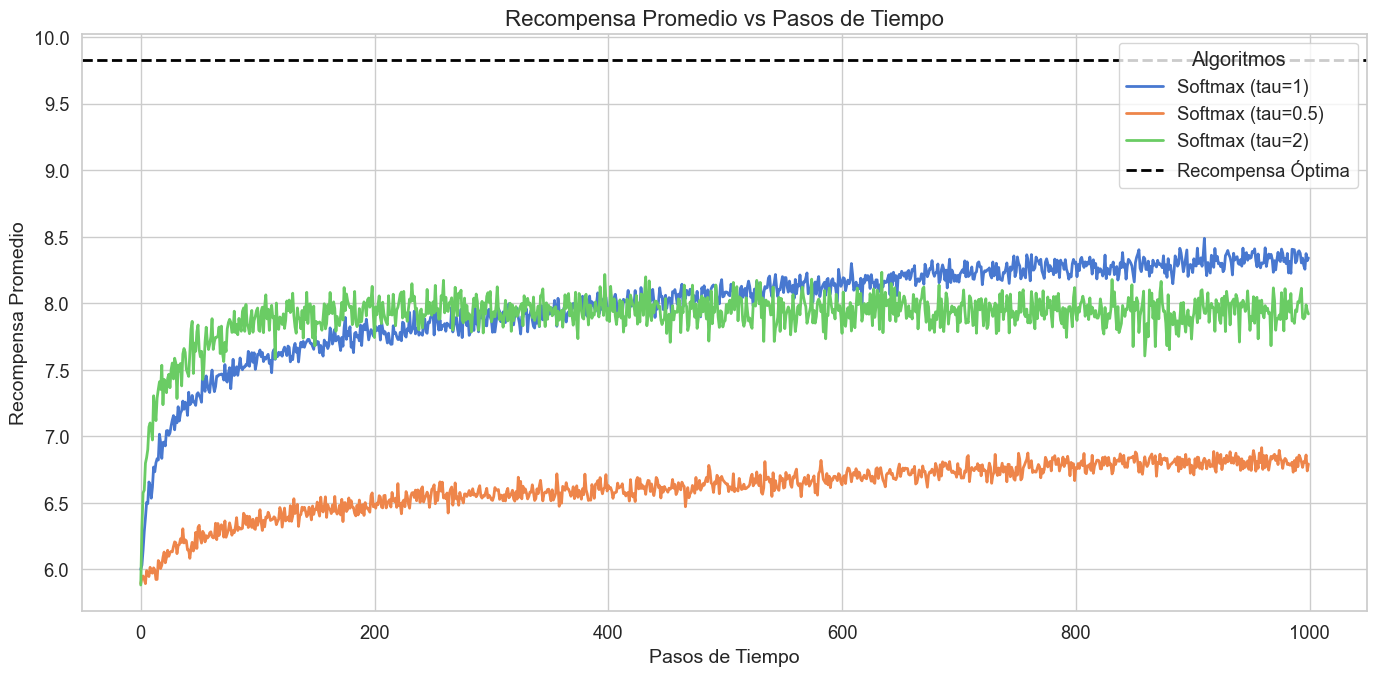

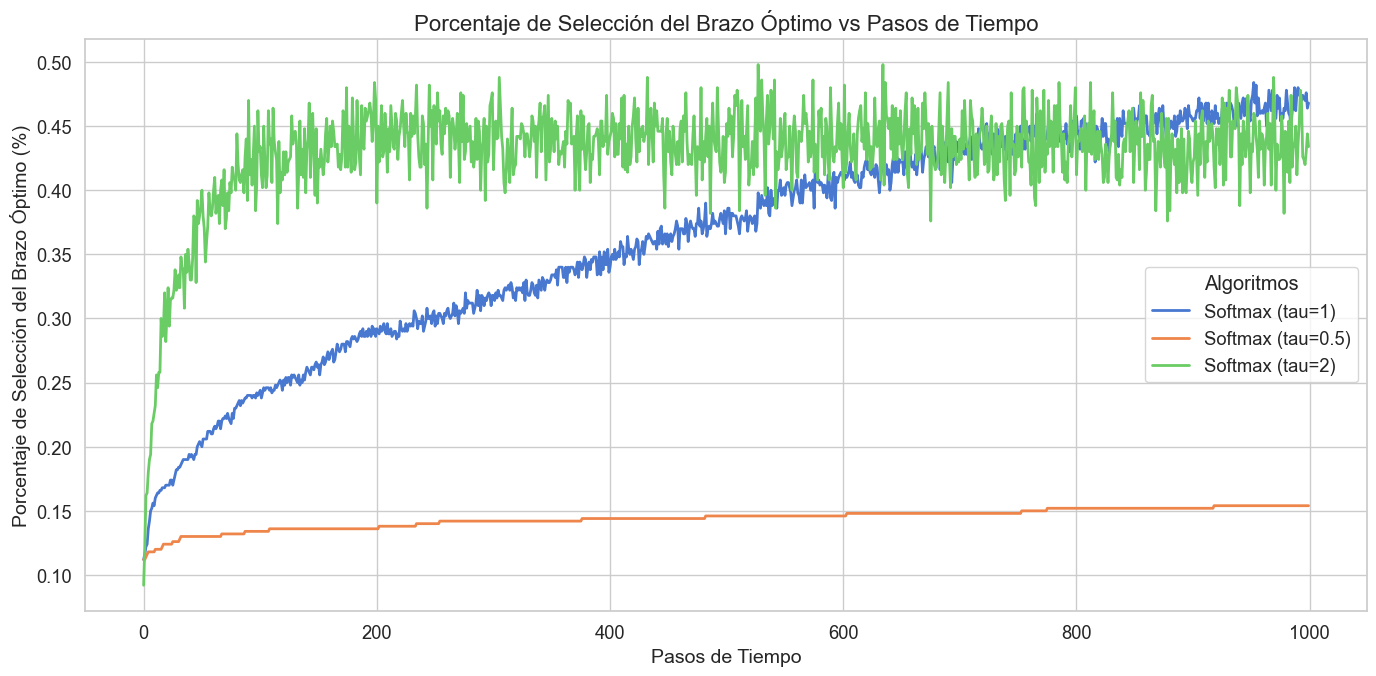


Estadísticas de brazos - Softmax (tau=1)
Brazo 1: Recompensa Promedio = 1.1307, Selecciones = 3
Brazo 2: Recompensa Promedio = 1.2749, Selecciones = 5
Brazo 3: Recompensa Promedio = 2.3429, Selecciones = 51
Brazo 4: Recompensa Promedio = 1.9750, Selecciones = 18
Brazo 5: Recompensa Promedio = 3.2338, Selecciones = 190
Brazo 6: Recompensa Promedio = 3.1750, Selecciones = 177
Brazo 7: Recompensa Promedio = 4.9355, Selecciones = 362 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 3.0460, Selecciones = 148
Brazo 9: Recompensa Promedio = 2.0162, Selecciones = 29
Brazo 10: Recompensa Promedio = 1.6871, Selecciones = 13


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


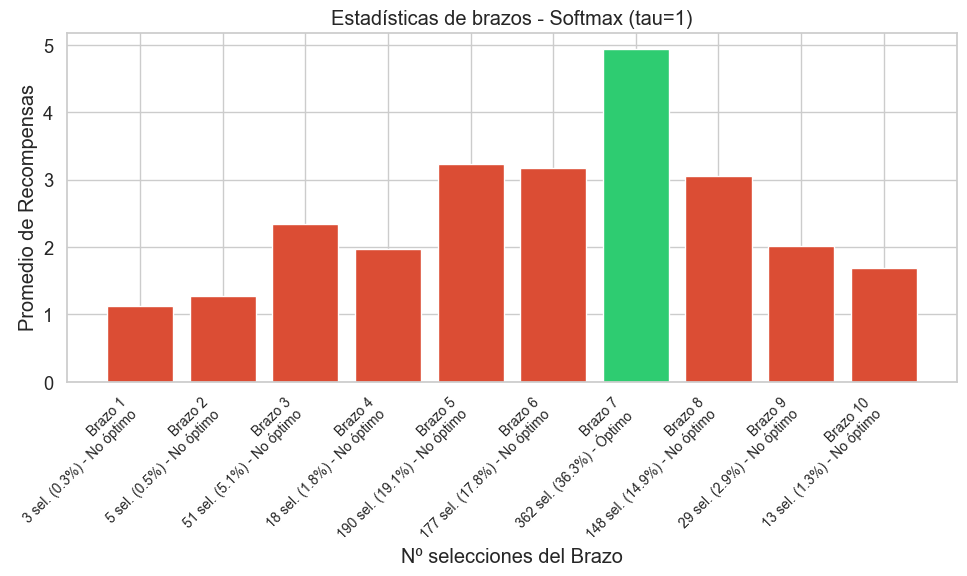


Estadísticas de brazos - Softmax (tau=0.5)
Brazo 1: Recompensa Promedio = 0.4159, Selecciones = 7
Brazo 2: Recompensa Promedio = 0.4422, Selecciones = 17
Brazo 3: Recompensa Promedio = 0.8581, Selecciones = 125
Brazo 4: Recompensa Promedio = 0.7668, Selecciones = 116
Brazo 5: Recompensa Promedio = 1.0634, Selecciones = 129
Brazo 6: Recompensa Promedio = 0.9882, Selecciones = 119
Brazo 7: Recompensa Promedio = 1.5138, Selecciones = 144 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 0.9873, Selecciones = 121
Brazo 9: Recompensa Promedio = 0.8157, Selecciones = 128
Brazo 10: Recompensa Promedio = 0.6759, Selecciones = 89


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


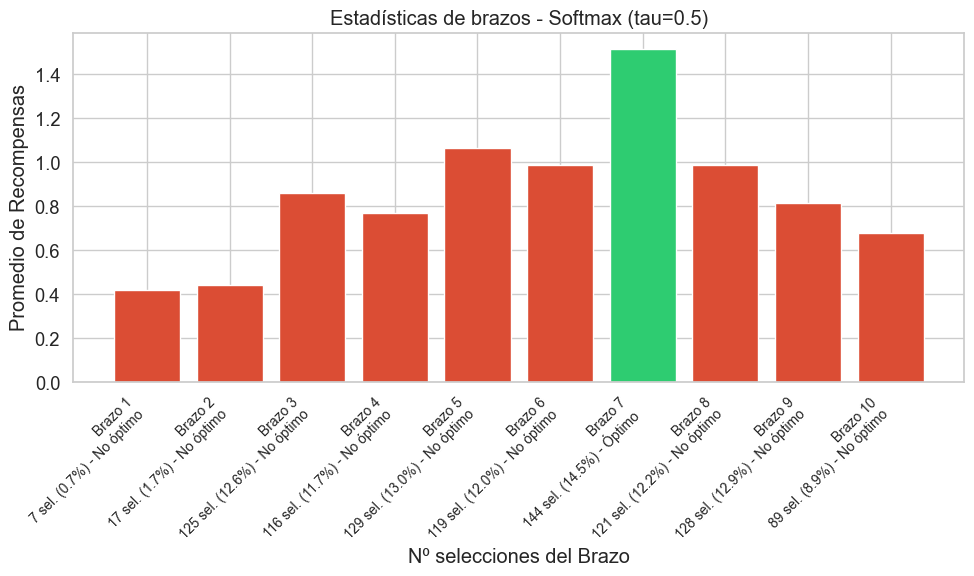


Estadísticas de brazos - Softmax (tau=2)
Brazo 1: Recompensa Promedio = 2.9876, Selecciones = 15
Brazo 2: Recompensa Promedio = 3.4315, Selecciones = 19
Brazo 3: Recompensa Promedio = 5.8397, Selecciones = 61
Brazo 4: Recompensa Promedio = 4.7150, Selecciones = 35
Brazo 5: Recompensa Promedio = 7.4289, Selecciones = 131
Brazo 6: Recompensa Promedio = 7.1943, Selecciones = 118
Brazo 7: Recompensa Promedio = 9.8276, Selecciones = 429 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 7.0639, Selecciones = 111
Brazo 9: Recompensa Promedio = 5.2854, Selecciones = 46
Brazo 10: Recompensa Promedio = 4.4418, Selecciones = 30


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


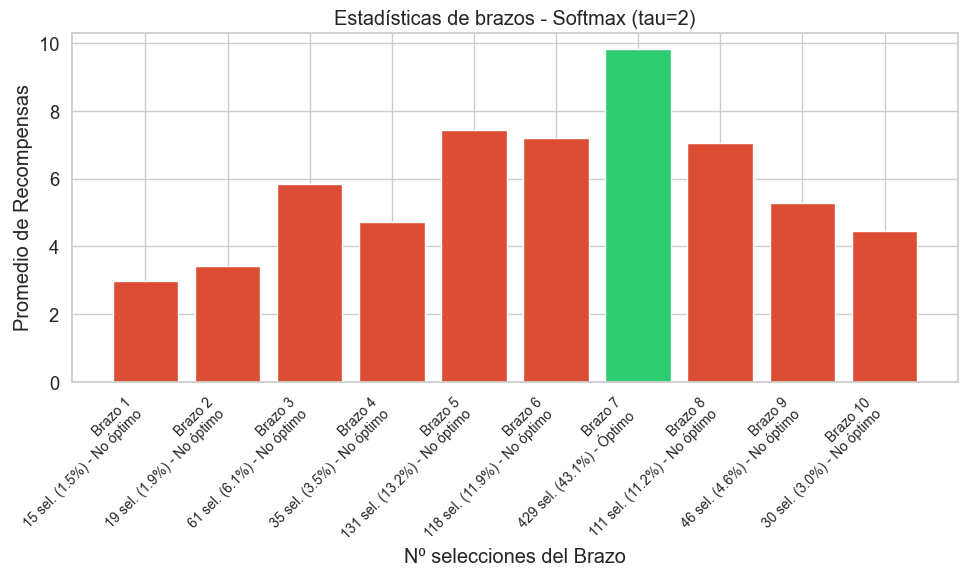

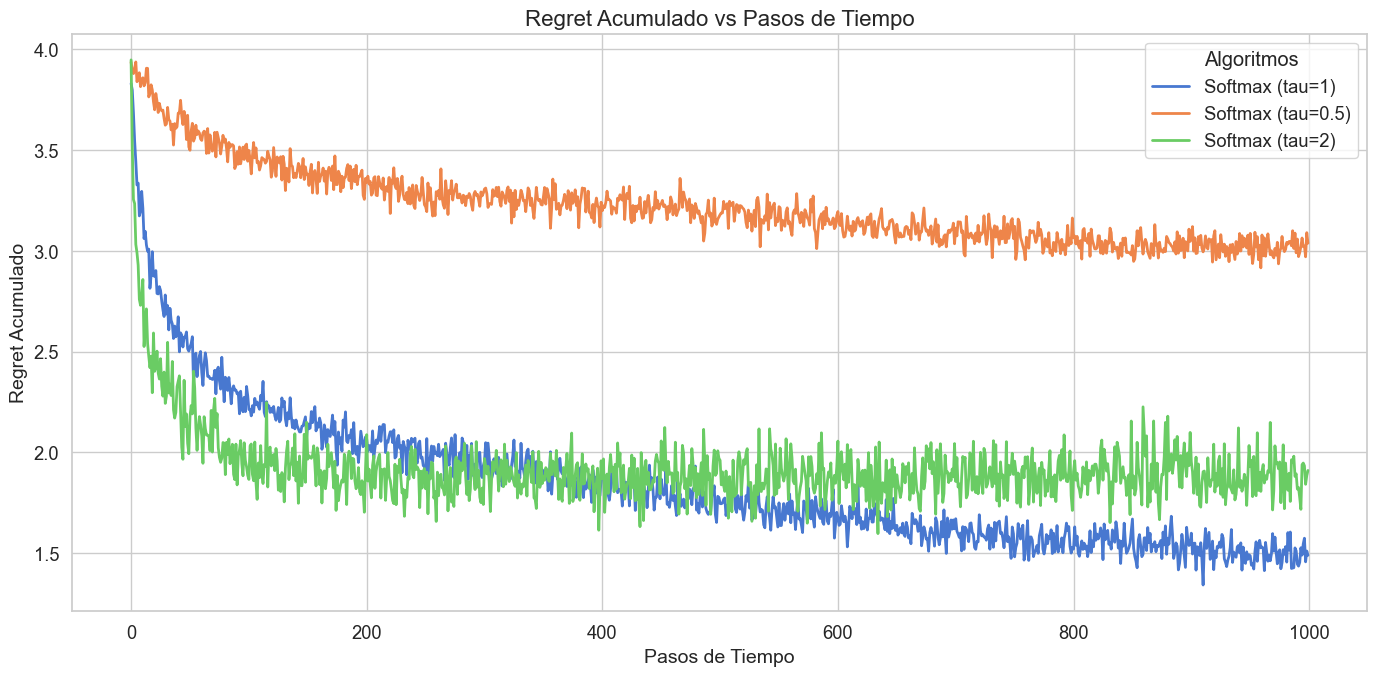

In [6]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Bernoulli``

In [7]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.16), ArmBernoulli(p=0.84), ArmBernoulli(p=0.12), ArmBernoulli(p=0.86), ArmBernoulli(p=0.06), ArmBernoulli(p=0.46), ArmBernoulli(p=0.33), ArmBernoulli(p=0.18), ArmBernoulli(p=0.59), ArmBernoulli(p=0.02)
Optimal arm: 4 with expected reward=0.86


### Visualización

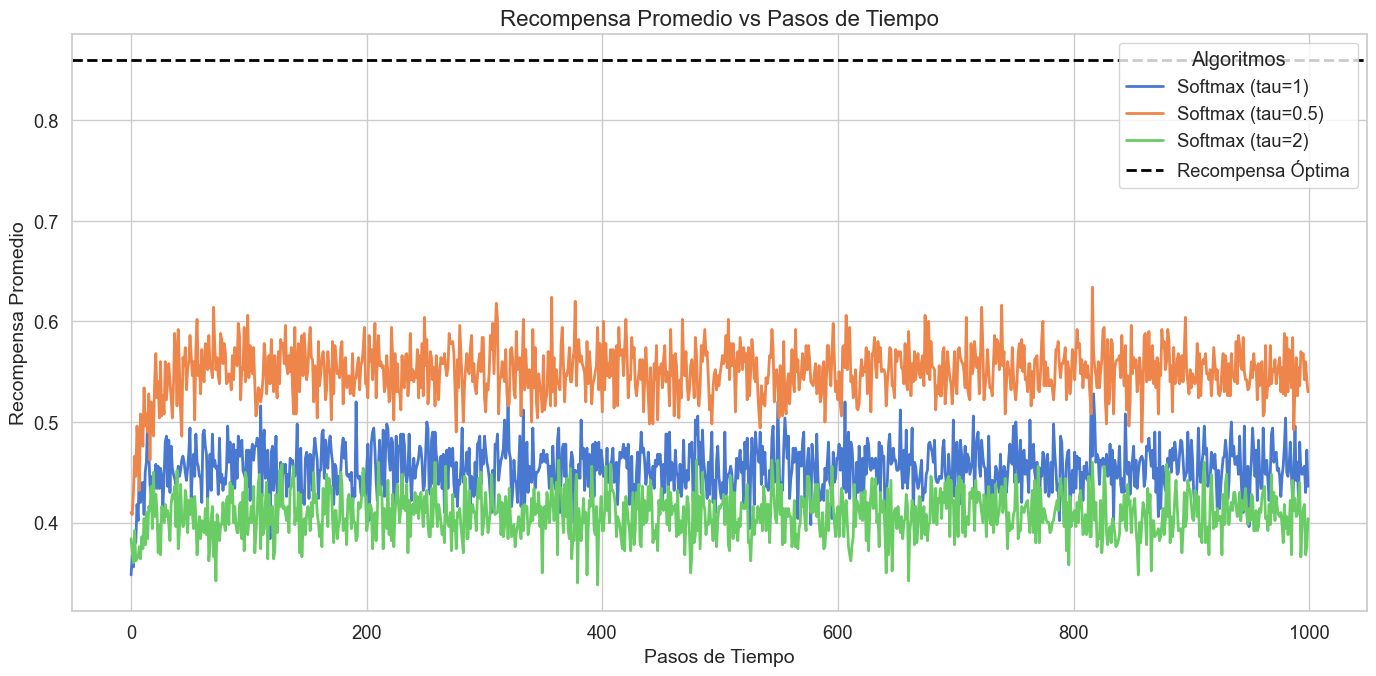

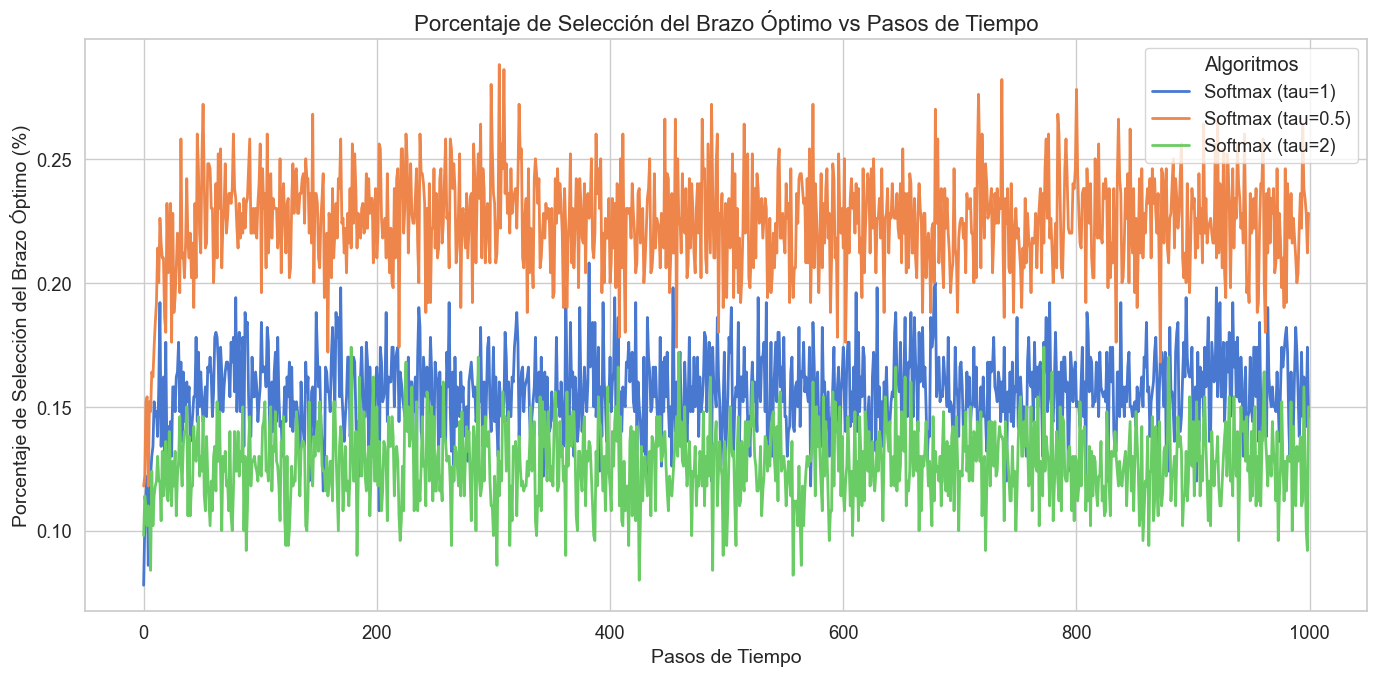


Estadísticas de brazos - Softmax (tau=1)
Brazo 1: Recompensa Promedio = 0.1555, Selecciones = 78
Brazo 2: Recompensa Promedio = 0.8367, Selecciones = 153
Brazo 3: Recompensa Promedio = 0.1199, Selecciones = 75
Brazo 4: Recompensa Promedio = 0.8592, Selecciones = 156 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 0.0592, Selecciones = 71
Brazo 6: Recompensa Promedio = 0.4589, Selecciones = 105
Brazo 7: Recompensa Promedio = 0.3304, Selecciones = 92
Brazo 8: Recompensa Promedio = 0.1761, Selecciones = 78
Brazo 9: Recompensa Promedio = 0.5882, Selecciones = 120
Brazo 10: Recompensa Promedio = 0.0196, Selecciones = 68


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


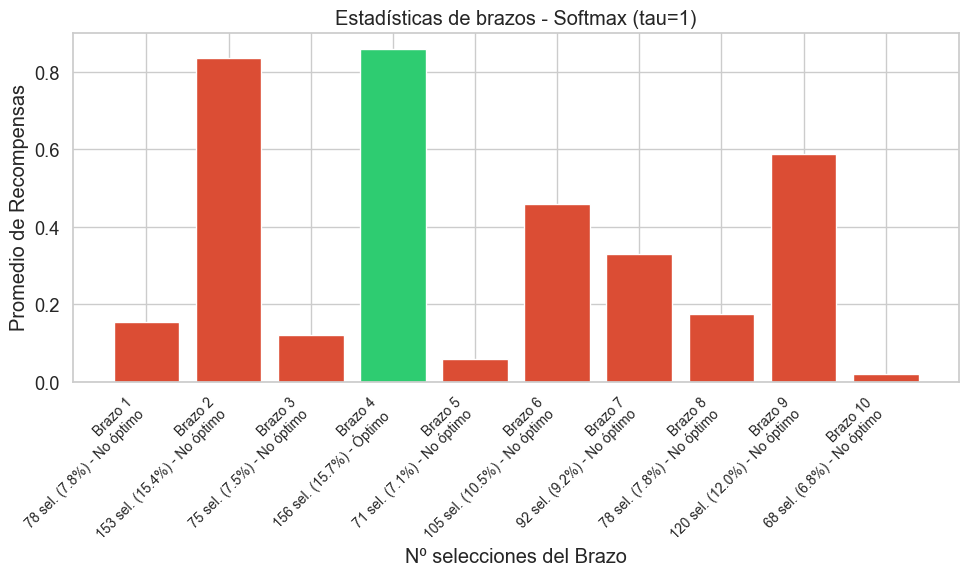

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - Softmax (tau=0.5)
Brazo 1: Recompensa Promedio = 0.1552, Selecciones = 56
Brazo 2: Recompensa Promedio = 0.8384, Selecciones = 214
Brazo 3: Recompensa Promedio = 0.1149, Selecciones = 50
Brazo 4: Recompensa Promedio = 0.8612, Selecciones = 224 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 0.0579, Selecciones = 46
Brazo 6: Recompensa Promedio = 0.4525, Selecciones = 100
Brazo 7: Recompensa Promedio = 0.3253, Selecciones = 77
Brazo 8: Recompensa Promedio = 0.1728, Selecciones = 58
Brazo 9: Recompensa Promedio = 0.5855, Selecciones = 129
Brazo 10: Recompensa Promedio = 0.0201, Selecciones = 43


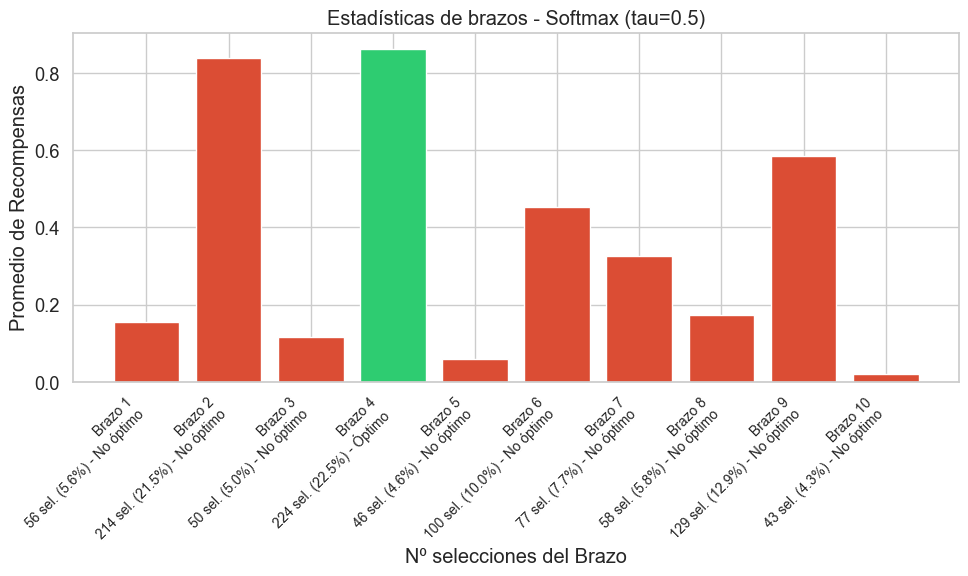


Estadísticas de brazos - Softmax (tau=2)
Brazo 1: Recompensa Promedio = 0.1629, Selecciones = 89
Brazo 2: Recompensa Promedio = 0.8406, Selecciones = 125
Brazo 3: Recompensa Promedio = 0.1175, Selecciones = 87
Brazo 4: Recompensa Promedio = 0.8601, Selecciones = 126 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 0.0598, Selecciones = 85
Brazo 6: Recompensa Promedio = 0.4550, Selecciones = 103
Brazo 7: Recompensa Promedio = 0.3340, Selecciones = 97
Brazo 8: Recompensa Promedio = 0.1783, Selecciones = 90
Brazo 9: Recompensa Promedio = 0.5911, Selecciones = 110
Brazo 10: Recompensa Promedio = 0.0199, Selecciones = 83


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


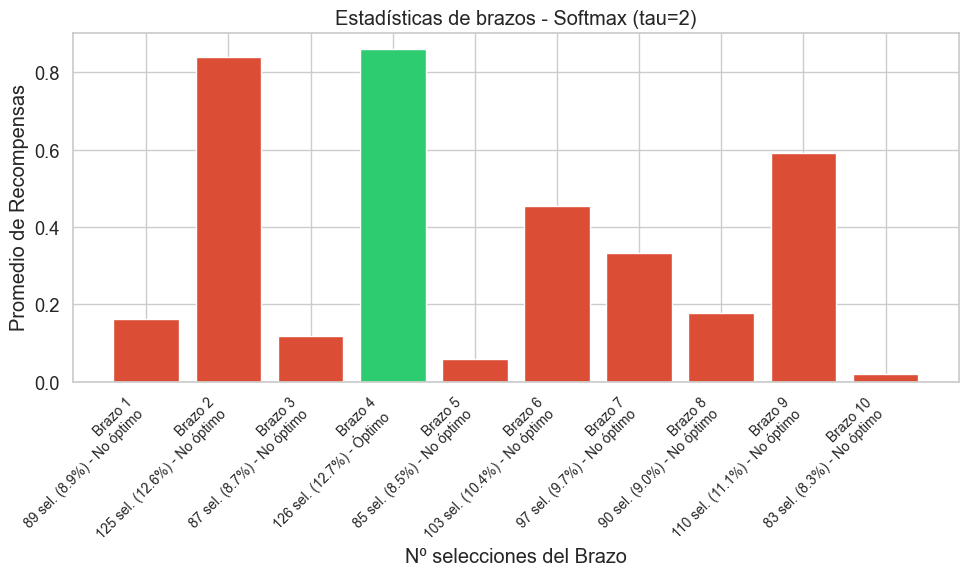

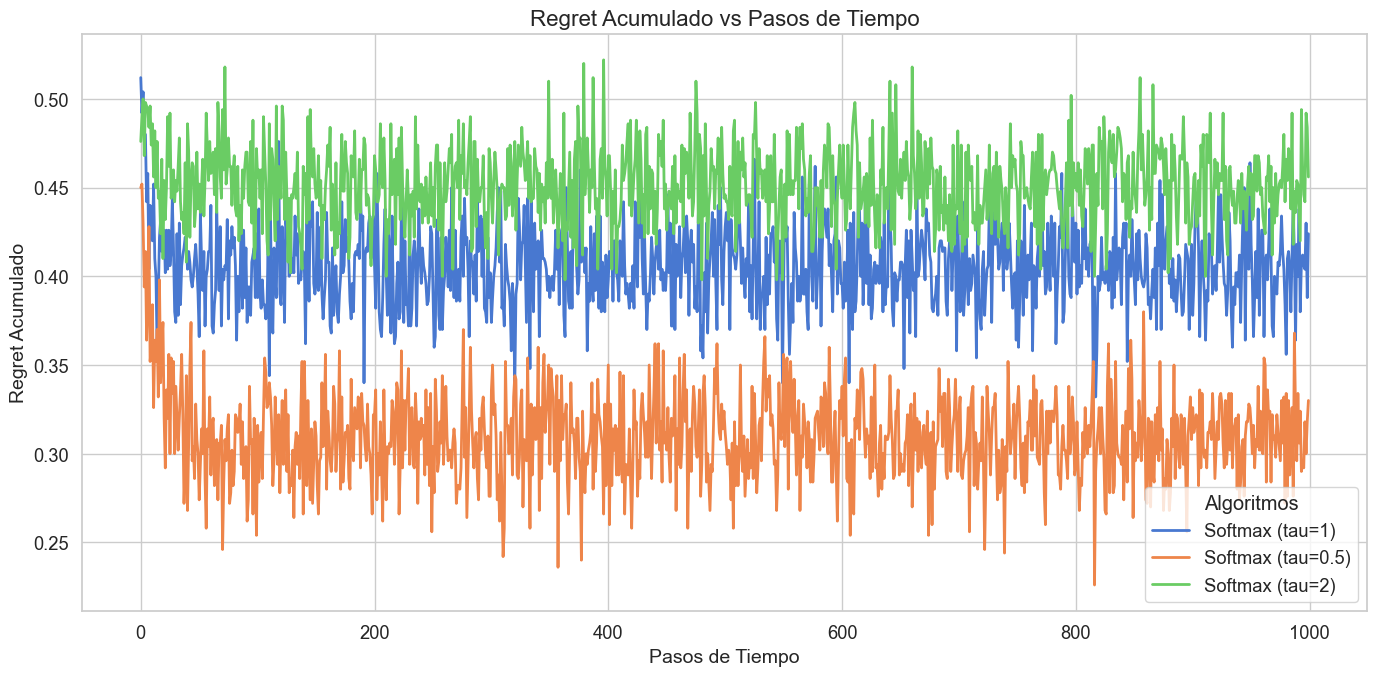

In [8]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Binomial``

In [9]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, tau=1), Softmax(k=k, tau=0.5), Softmax(k=k, tau=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.32), ArmBinomial(n=10, p=0.85), ArmBinomial(n=10, p=0.6), ArmBinomial(n=10, p=0.19), ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.52), ArmBinomial(n=10, p=0.46), ArmBinomial(n=10, p=0.9), ArmBinomial(n=10, p=0.35), ArmBinomial(n=10, p=0.69)
Optimal arm: 8 with expected reward=9.0


### Visualización

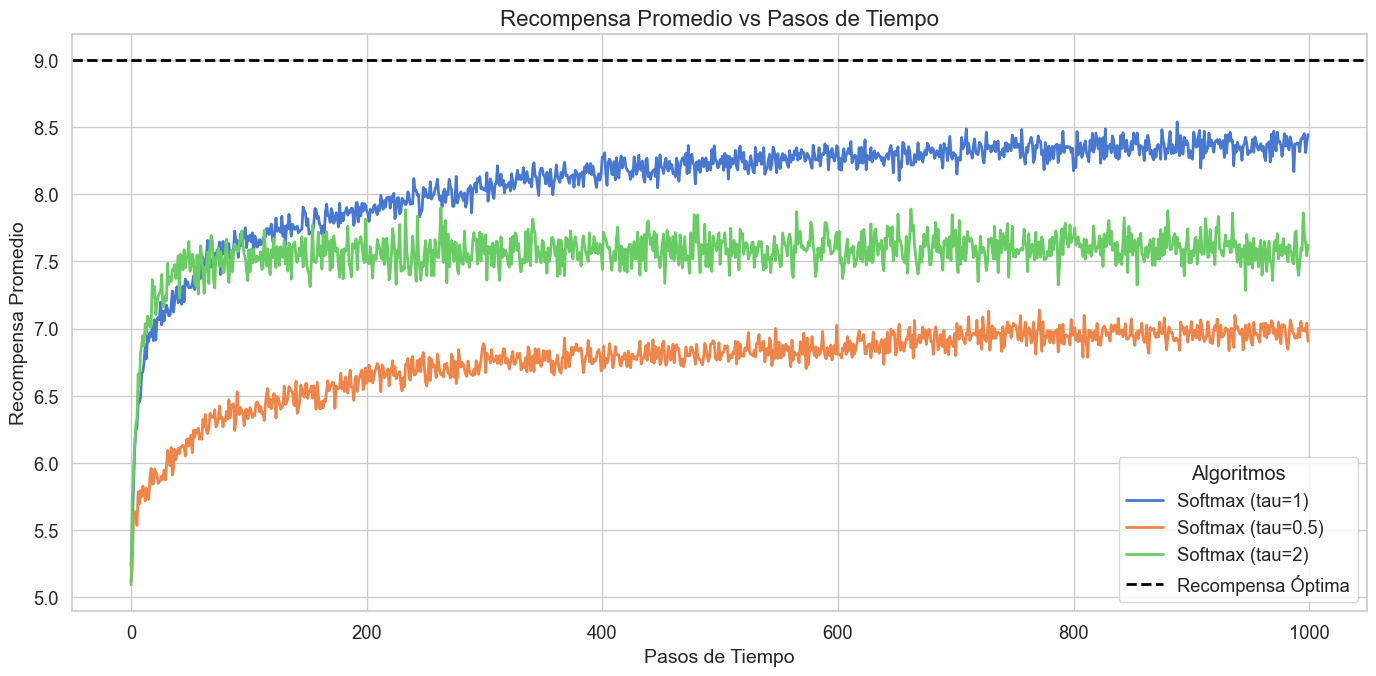

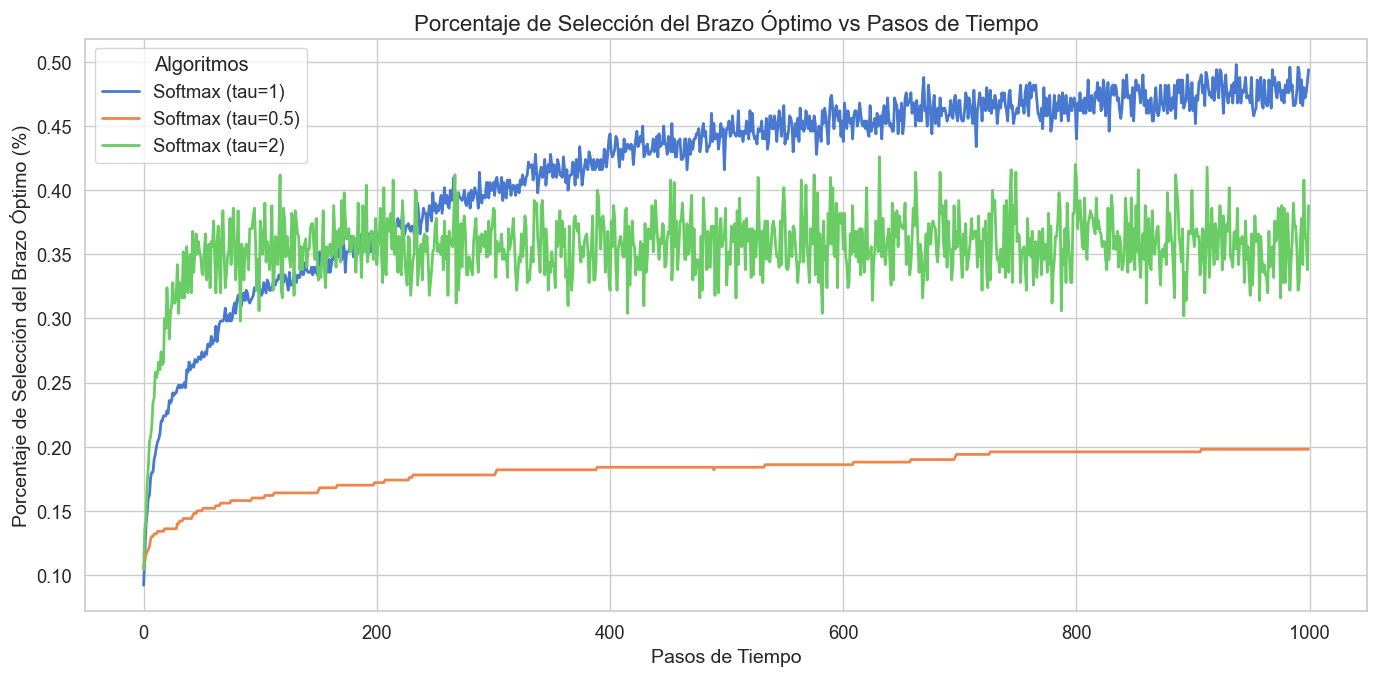


Estadísticas de brazos - Softmax (tau=1)
Brazo 1: Recompensa Promedio = 1.1369, Selecciones = 4
Brazo 2: Recompensa Promedio = 4.1327, Selecciones = 316
Brazo 3: Recompensa Promedio = 2.6036, Selecciones = 62
Brazo 4: Recompensa Promedio = 0.7018, Selecciones = 1
Brazo 5: Recompensa Promedio = 0.8644, Selecciones = 2
Brazo 6: Recompensa Promedio = 2.0853, Selecciones = 29
Brazo 7: Recompensa Promedio = 1.7055, Selecciones = 15
Brazo 8: Recompensa Promedio = 5.0394, Selecciones = 416 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 1.1844, Selecciones = 4
Brazo 10: Recompensa Promedio = 2.8844, Selecciones = 147


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


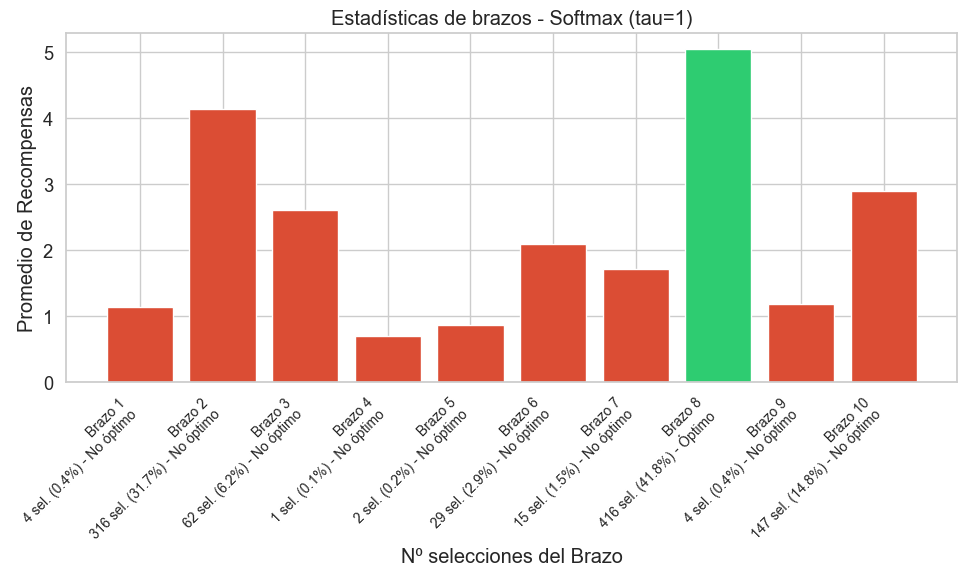

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - Softmax (tau=0.5)
Brazo 1: Recompensa Promedio = 0.5192, Selecciones = 16
Brazo 2: Recompensa Promedio = 1.6335, Selecciones = 175
Brazo 3: Recompensa Promedio = 1.0796, Selecciones = 171
Brazo 4: Recompensa Promedio = 0.2308, Selecciones = 1
Brazo 5: Recompensa Promedio = 0.2900, Selecciones = 2
Brazo 6: Recompensa Promedio = 0.8161, Selecciones = 131
Brazo 7: Recompensa Promedio = 0.7781, Selecciones = 119
Brazo 8: Recompensa Promedio = 1.7829, Selecciones = 181 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 0.4907, Selecciones = 25
Brazo 10: Recompensa Promedio = 1.2827, Selecciones = 174


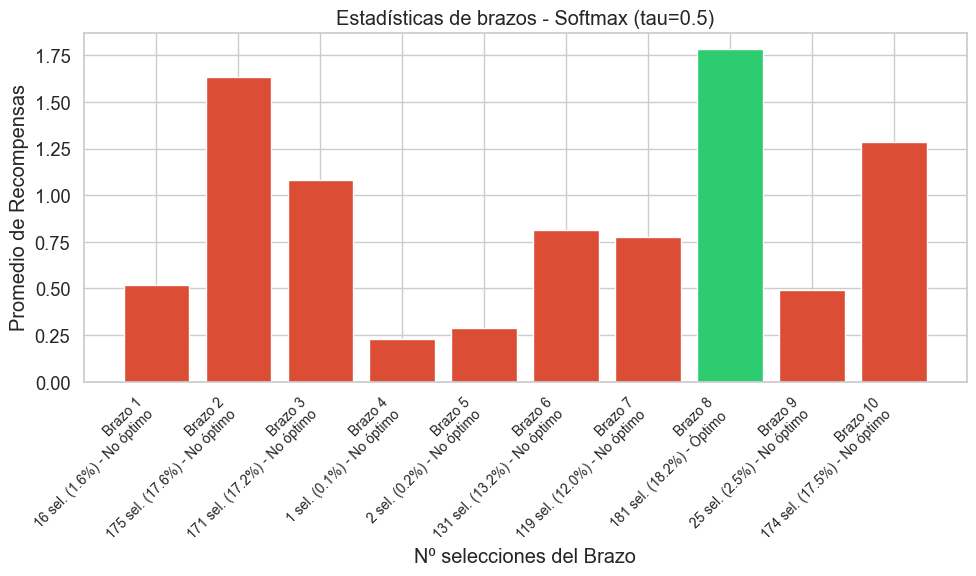


Estadísticas de brazos - Softmax (tau=2)
Brazo 1: Recompensa Promedio = 3.0944, Selecciones = 19
Brazo 2: Recompensa Promedio = 8.5025, Selecciones = 276
Brazo 3: Recompensa Promedio = 5.9502, Selecciones = 80
Brazo 4: Recompensa Promedio = 1.8467, Selecciones = 11
Brazo 5: Recompensa Promedio = 2.3957, Selecciones = 14
Brazo 6: Recompensa Promedio = 5.1438, Selecciones = 55
Brazo 7: Recompensa Promedio = 4.5209, Selecciones = 39
Brazo 8: Recompensa Promedio = 8.9812, Selecciones = 354 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 3.4759, Selecciones = 23
Brazo 10: Recompensa Promedio = 6.8636, Selecciones = 124


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


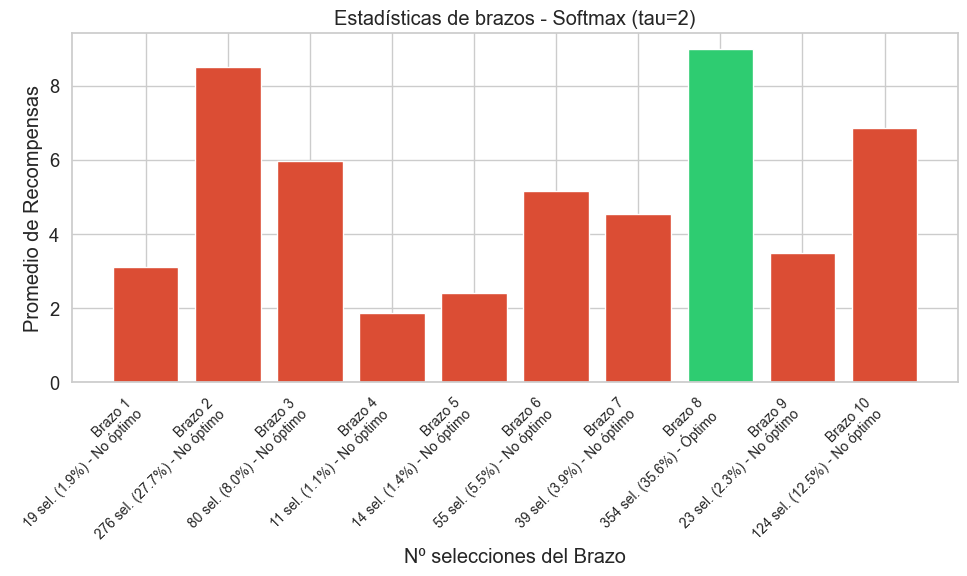

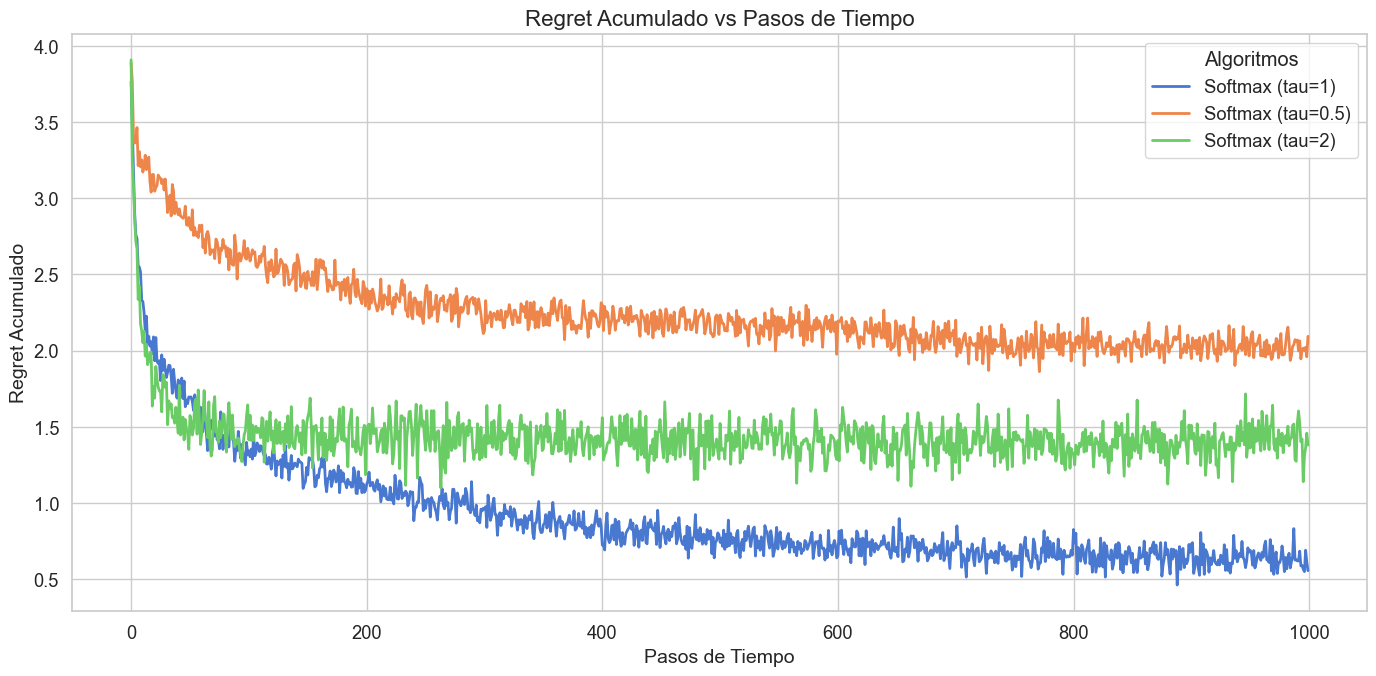

In [10]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis